In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import linregress, alpha
import cartopy.crs as ccrs
import matplotlib.cm as cm
from scipy.ndimage.filters import gaussian_filter
# import numpy.random
# import os as os
# from os import listdir
# from os.path import isfile, join
# from xml.sax import parse
# import pyproj
# from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
# from shapely.geometry import Point

/tmp/ipykernel_6324/1861881907.py:8: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


In [2]:
ua2016 = pd.read_csv("./Data/2016/csv/Unfallorte_2016_LinRef.txt", sep=";", decimal=",")
ua2017 = pd.read_csv("./Data/2017/csv/Unfallorte2017_LinRef.txt", sep=";", decimal=",")
ua2018 = pd.read_csv("./Data/2018/csv/Unfallorte2018_LinRef.txt", sep=";", decimal=",")
ua2019 = pd.read_csv("./Data/2019/csv/Unfallorte2019_LinRef.txt", sep=";", decimal=",")
ua2020 = pd.read_csv("./Data/2020/csv/Unfallorte2020_LinRef.csv", sep=";", decimal=",")
ua2021 = pd.read_csv("./Data/2021/csv/Unfallorte_2021_LinRef.txt", sep=";", decimal=",")
ua2022 = pd.read_csv("./Data/2022/csv/Unfallorte2022_LinRef.csv", sep=";", decimal=",")
ua2023 = pd.read_csv("./Data/2023/csv/Unfallorte2023_LinRef.csv", sep=";", decimal=",")

ua_leip_20162020 = pd.read_csv("Data/unfallatlasleipzig20162020.csv")

einwohn_leip = pd.read_csv("./Data/Leipzig/Bevölkerungsbestand_Einwohner.csv", sep=",")

einwohn_sax = pd.read_csv("./Data/Sachsen/Einwohner_Sachsen.csv", sep=";")


/tmp/ipykernel_6324/832639538.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  ua2017 = pd.read_csv("./Data/2017/csv/Unfallorte2017_LinRef.txt", sep=";", decimal=",")
/tmp/ipykernel_6324/832639538.py:6: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  ua2021 = pd.read_csv("./Data/2021/csv/Unfallorte_2021_LinRef.txt", sep=";", decimal=",")
/tmp/ipykernel_6324/832639538.py:7: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  ua2022 = pd.read_csv("./Data/2022/csv/Unfallorte2022_LinRef.csv", sep=";", decimal=",")
/tmp/ipykernel_6324/832639538.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  ua2023 = pd.read_csv("./Data/2023/csv/Unfallorte2023_LinRef.csv", sep=";", decimal=",")


In [3]:
einwohn_sax = einwohn_sax.rename(columns = {"Kreis":"KREIS"})

In [4]:
leip_str_sh = gpd.read_file("./Data/Leipzig/Radwege/shape/roads.shp")

<Axes: >

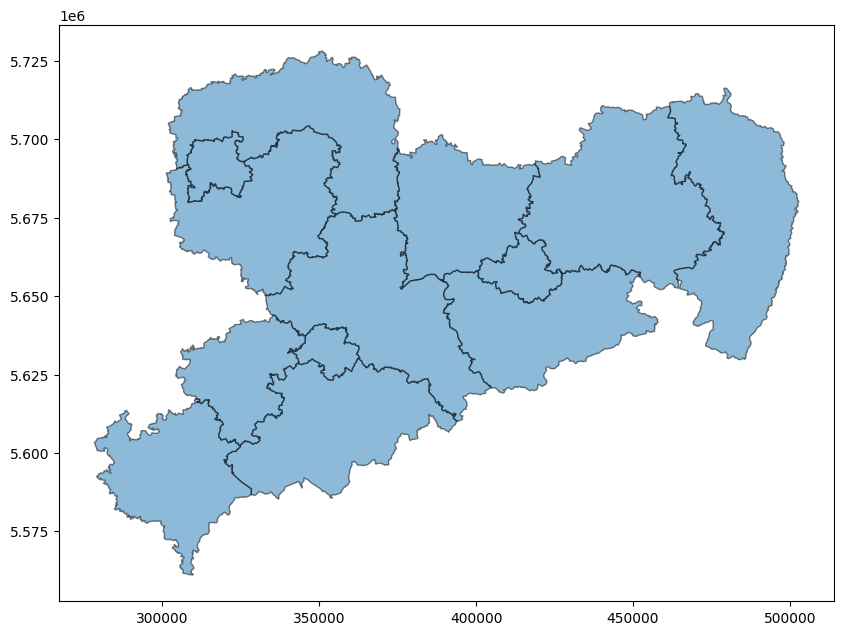

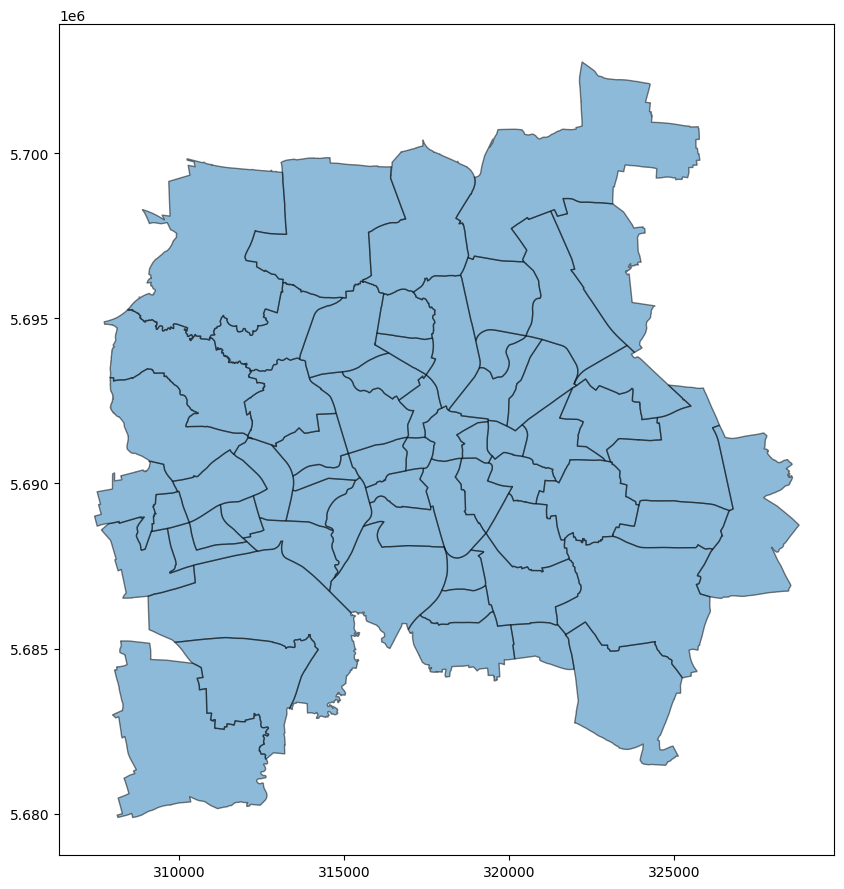

In [5]:
#Shapefiles von Sachsen und Leipzig einlesen
# https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::neighborhood-map-atlas-districts/about
sax_df = gpd.read_file("./Data/Sachsen/kreis.shp")
leip_df = gpd.read_file("./Data/Leipzig/ot.shp")

sax_df.plot(figsize=(10,15), alpha=0.5, edgecolor='k')
leip_df.plot(figsize=(10,15), alpha=0.5, edgecolor='k')

In [6]:
sax_df.to_crs(epsg=4269,inplace=True)

In [7]:
leip_df.to_crs(epsg=4269,inplace=True)

In [8]:
#Geometry Spalte erzeugen
    #TODO für alle Jahre durchführen!
#ua_leip_20162020["geometry"] = ua_leip_20162020["XGCSWGS84"]

ua_leip_20162020 = gpd.GeoDataFrame(
    ua_leip_20162020,
    geometry = gpd.points_from_xy(
        x = ua_leip_20162020.XGCSWGS84,
        y = ua_leip_20162020.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2016 = gpd.GeoDataFrame(
    ua2016,
    geometry = gpd.points_from_xy(
        x = ua2016.XGCSWGS84,
        y = ua2016.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2017 = gpd.GeoDataFrame(
    ua2017,
    geometry = gpd.points_from_xy(
        x = ua2017.XGCSWGS84,
        y = ua2017.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2018 = gpd.GeoDataFrame(
    ua2018,
    geometry = gpd.points_from_xy(
        x = ua2018.XGCSWGS84,
        y = ua2018.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2019 = gpd.GeoDataFrame(
    ua2019,
    geometry = gpd.points_from_xy(
        x = ua2019.XGCSWGS84,
        y = ua2019.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2020 = gpd.GeoDataFrame(
    ua2020,
    geometry = gpd.points_from_xy(
        x = ua2020.XGCSWGS84,
        y = ua2020.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2021 = gpd.GeoDataFrame(
    ua2021,
    geometry = gpd.points_from_xy(
        x = ua2021.XGCSWGS84,
        y = ua2021.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2022 = gpd.GeoDataFrame(
    ua2022,
    geometry = gpd.points_from_xy(
        x = ua2022.XGCSWGS84,
        y = ua2022.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2023 = gpd.GeoDataFrame(
    ua2023,
    geometry = gpd.points_from_xy(
        x = ua2023.XGCSWGS84,
        y = ua2023.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

In [9]:
#Alle Dataframes einlesen
#
# dir_path = r"./Data"
# count = 0
# files = []
# data_frames = {}
#
# for path in os.listdir(dir_path):
#
#     if os.path.isdir(os.path.join(dir_path, path)):
#         count += 1
#
#     csv_path = dir_path + "/" + path + "/csv"
#
#     file = [f for f in listdir(csv_path) if isfile(join(csv_path, f))]
#     files.extend(file)
#
#         # dynamically create key
#     key = "ua" + path
#     # calculate value
#     value = pd.read_csv(csv_path + "/" + files[count-1]) #hier evtl  sep=";", decimal=",") einfügen
#     data_frames[key] = value
#
#
# print(data_frames)

(array([51.225, 51.25 , 51.275, 51.3  , 51.325, 51.35 , 51.375, 51.4  ,
        51.425, 51.45 ]),
 [Text(0, 51.225, '51.225'),
  Text(0, 51.25, '51.250'),
  Text(0, 51.275, '51.275'),
  Text(0, 51.300000000000004, '51.300'),
  Text(0, 51.325, '51.325'),
  Text(0, 51.35, '51.350'),
  Text(0, 51.375, '51.375'),
  Text(0, 51.4, '51.400'),
  Text(0, 51.425000000000004, '51.425'),
  Text(0, 51.45, '51.450')])

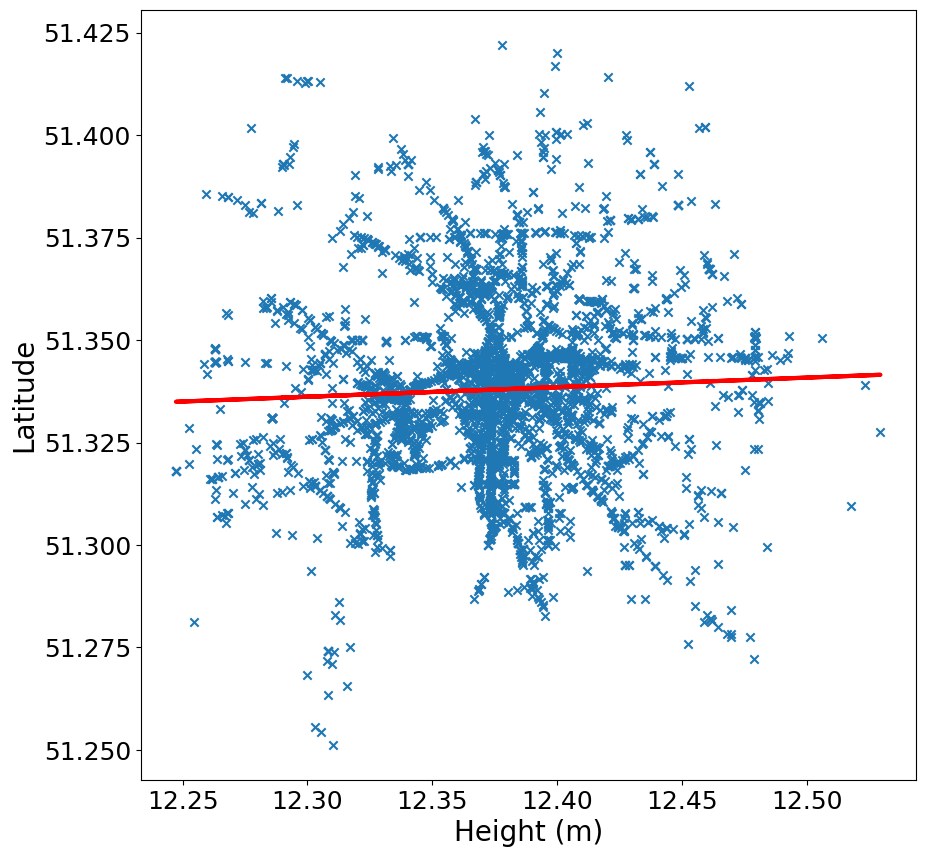

In [10]:
dataframe = ua_leip_20162020[["XGCSWGS84","YGCSWGS84"]]

x = dataframe.XGCSWGS84
y = dataframe.YGCSWGS84

stats = linregress(x, y)

m = stats.slope
b = stats.intercept

# Change the default figure size
plt.figure(figsize=(10,10))

# Change the default marker for the scatter from circles to x's
plt.scatter(x, y, marker='x')

# Set the linewidth on the regression line to 3px
plt.plot(x, m * x + b, color="red", linewidth=3)

# Add x and y lables, and set their font size
plt.xlabel("Height (m)", fontsize=20)
plt.ylabel("Latitude", fontsize=20)

# Set the font size of the number lables on the axes
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

#plt.savefig("python-linear-reg-custom.png")


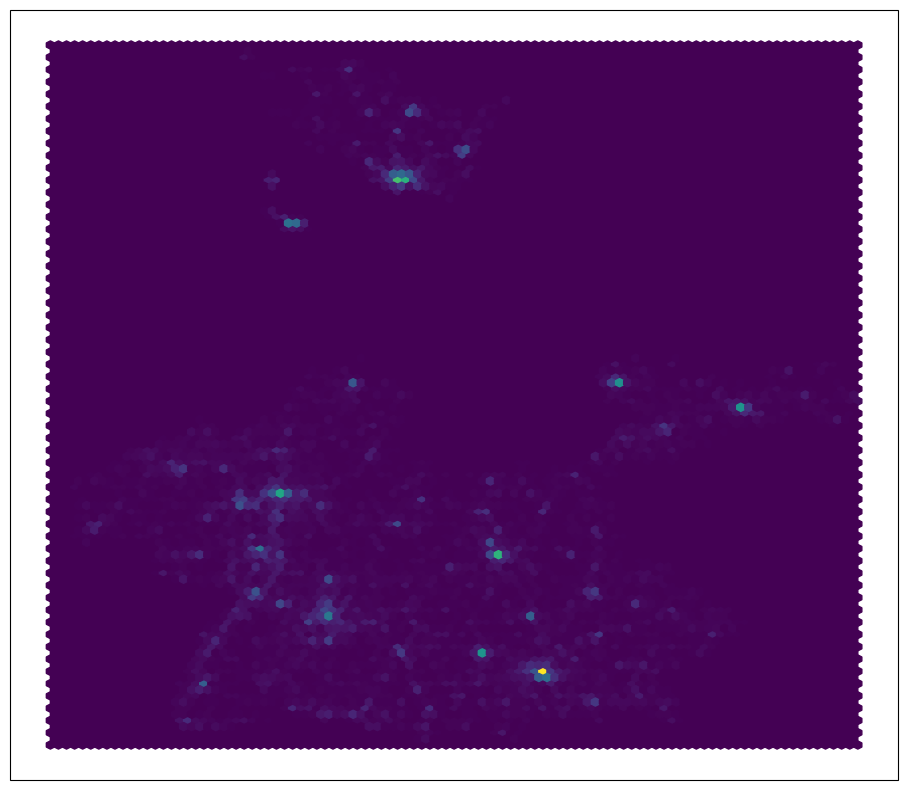

In [11]:
plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.Mercator())
ax.coastlines('10m')

# ax.xaxis.set_visible(True)
# ax.yaxis.set_visible(True)
#
#ax.set_yticks([52,53,54,55], crs=ccrs.PlateCarree())
# ax.set_xticks([-8, -6, -4, -2], crs=ccrs.PlateCarree())
#
# lon_formatter = LongitudeFormatter(zero_direction_label=True)
# lat_formatter = LatitudeFormatter()
#
# ax.xaxis.set_major_formatter(lon_formatter)
# ax.yaxis.set_major_formatter(lat_formatter)
#
# ax.set_extent([9, 10, 52, 55])
#
plt.hexbin(ua2016["XGCSWGS84"], ua2016["YGCSWGS84"])

# #plt.savefig("munros.png")


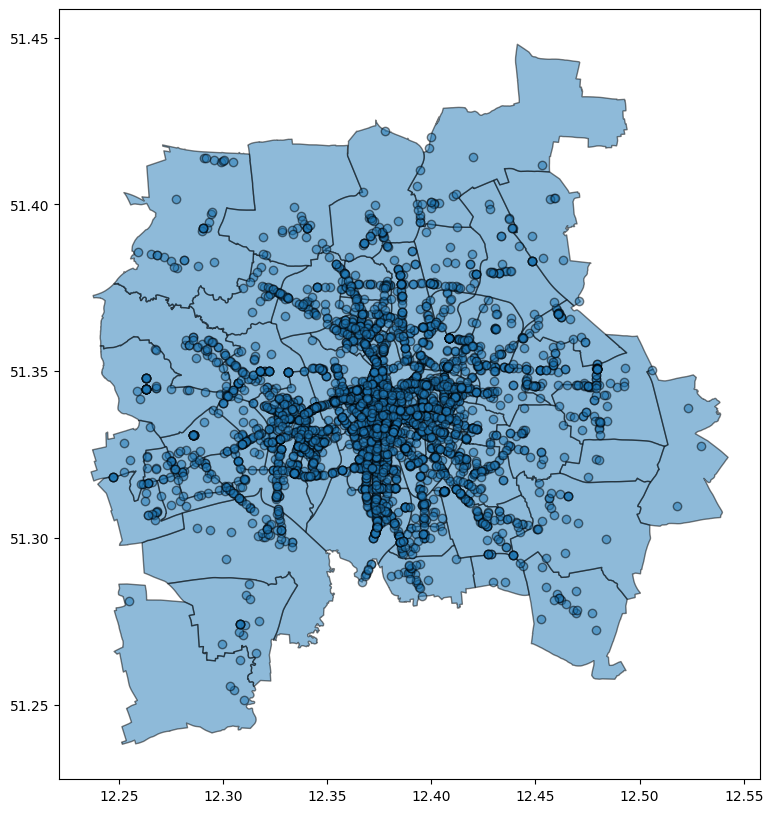

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))
leip_df.plot(ax=ax, alpha=0.5, edgecolor='k')
ua_leip_20162020.geometry.plot(ax=ax, alpha=0.5, edgecolor='k')
plt.show()

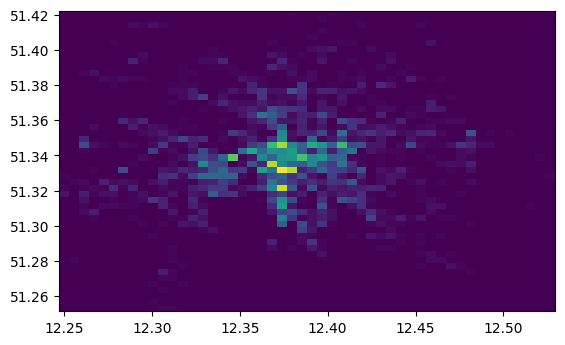

In [13]:
# Generate some test data
x = ua_leip_20162020.XGCSWGS84
y = ua_leip_20162020.YGCSWGS84

heatmap, xedges, yedges = np.histogram2d(x, y, bins=50)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.clf()
plt.imshow(heatmap.T, extent=extent, origin='lower')
plt.show()

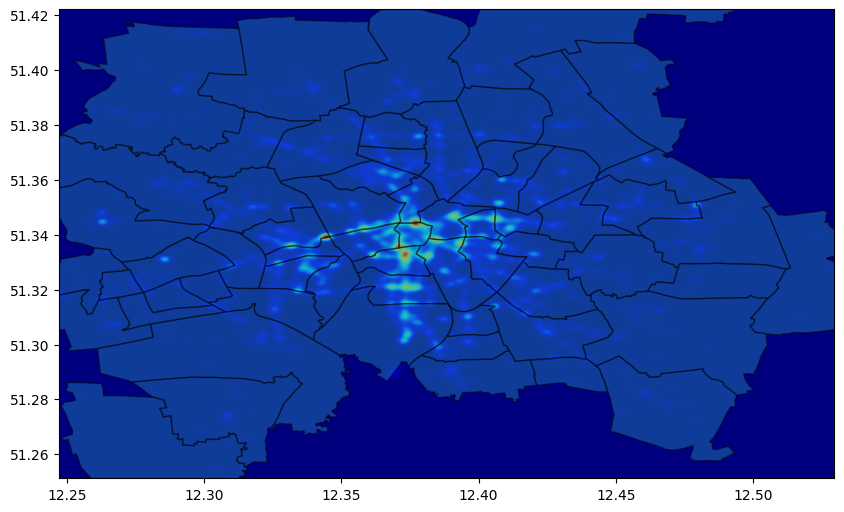

In [14]:
def myplot(x, y, s, bins=1000):
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    heatmap = gaussian_filter(heatmap, sigma=s)

    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    return heatmap.T, extent


fig, ax = plt.subplots(figsize=(10, 10))
leip_df.plot(ax=ax, alpha=0.5, edgecolor='k')
#ua_leip_20162020.geometry.plot(ax=ax, alpha=0.5, edgecolor='k')

# Generate some test data
x = ua_leip_20162020.XGCSWGS84
y = ua_leip_20162020.YGCSWGS84

img, extent = myplot(x, y, 5)
ax.imshow(img, extent=extent, origin='lower', cmap=cm.jet)

plt.show()

In [15]:
einwohn_leip = einwohn_leip.rename(columns = {"Gebiet":"Name"})
einwohn_leip_gsmt = einwohn_leip.loc[einwohn_leip["Sachmerkmal"]=="Einwohner insgesamt"]
shape_einwohn_leip = leip_df.merge(einwohn_leip_gsmt, on="Name", how="left")

In [16]:
uf_pro_ST_raw = ua_leip_20162020.sjoin(leip_df, how="inner", predicate='intersects')
uf_pro_ST = uf_pro_ST_raw["Name"].value_counts()

/home/fabian/PycharmProjects/DSH_Projekt/DigitalSpacialHumanities/.venv/lib/python3.12/site-packages/geopandas/geodataframe.py:2560: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:4269

  return geopandas.sjoin(


In [17]:
shape_einwohn_leip_uf = shape_einwohn_leip.merge(uf_pro_ST, on="Name", how="left")
shape_einwohn_leip_uf["Uf_Ew"] = shape_einwohn_leip_uf["count"]/shape_einwohn_leip_uf["2018"]
shape_einwohn_leip_uf["Uf_Ew1000"] = shape_einwohn_leip_uf["count"]/shape_einwohn_leip_uf["2018"]*1000

In [18]:
ua2016sax_rad = ua2016.loc[(ua2016["ULAND"]==14) & (ua2016["IstRad"]==1)]
uf_pro_Kreis_raw_2016 = ua2016sax_rad.sjoin(sax_df, how="inner", predicate='intersects')
uf_pro_Kreis_2016 = uf_pro_Kreis_raw_2016["KREIS"].value_counts()
shape_sax_rad = sax_df.merge(uf_pro_Kreis_2016, on="KREIS", how="left")

/home/fabian/PycharmProjects/DSH_Projekt/DigitalSpacialHumanities/.venv/lib/python3.12/site-packages/geopandas/geodataframe.py:2560: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:4269

  return geopandas.sjoin(


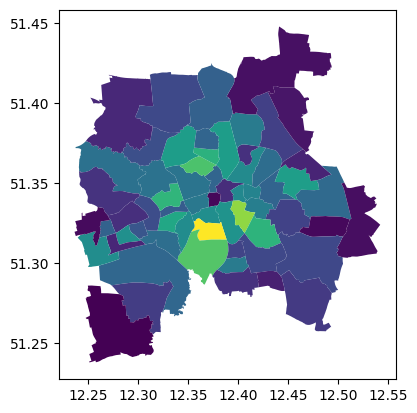

In [19]:
 # Plot by population

shape_einwohn_leip.plot(column="2016");


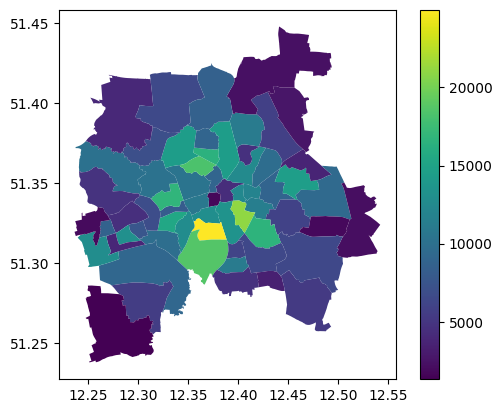

In [20]:
# Plot population estimates with an accurate legend

shape_einwohn_leip.plot(column='2016', legend=True);

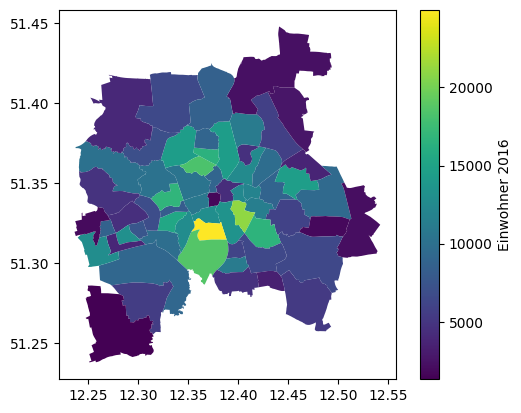

In [21]:
# Plot population estimates with an accurate legend

shape_einwohn_leip.plot(

    column="2016",

    legend=True,

    legend_kwds={"label": "Einwohner 2016"},

);


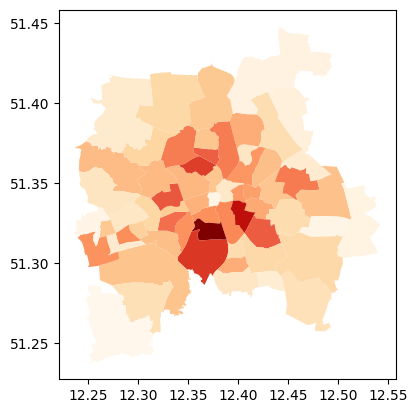

In [22]:
shape_einwohn_leip.plot(column='2016', cmap='OrRd');

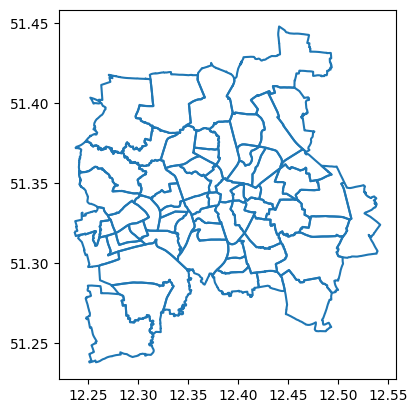

In [23]:
shape_einwohn_leip.boundary.plot();

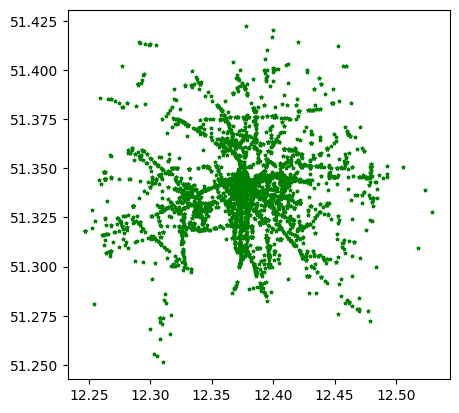

In [24]:
# Look at capitals
# Note use of standard `pyplot` line style options

ua_leip_20162020.plot(marker='*', color='green', markersize=5);

# Check crs

ua_leip_20162020 = ua_leip_20162020.to_crs(shape_einwohn_leip.crs)

# Now you can overlay over the outlines


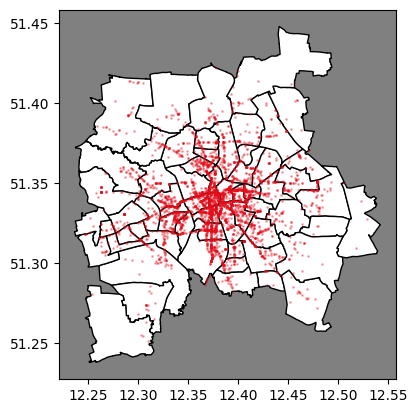

In [25]:
base = shape_einwohn_leip.plot(color='white', edgecolor='black')
base.set_facecolor("grey")

ua_leip_20162020.plot(ax=base, marker='o', color='#e40d1a', markersize=1, alpha=0.3);

plt.savefig("./plots/1.png")

NameError: name 'chicago' is not defined

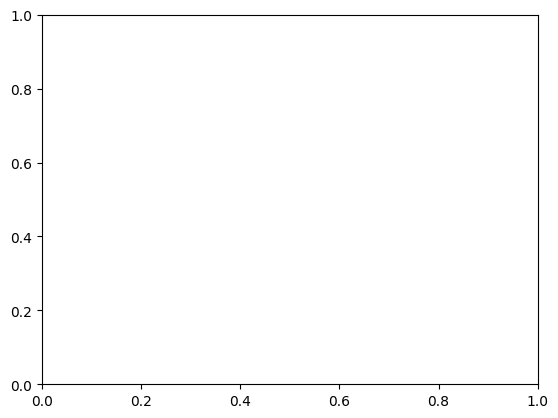

In [26]:
fig, ax = plt.subplots()

chicago.plot(ax=ax, color='white', edgecolor='black')

groceries.plot(ax=ax, marker='o', color='red', markersize=5)

plt.show();

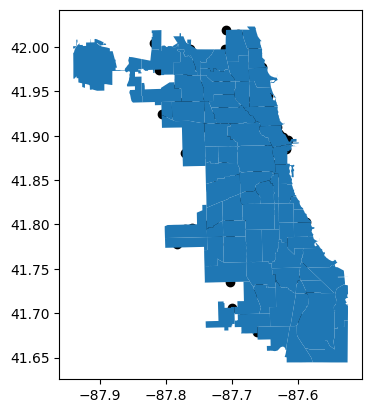

In [61]:
ax = groceries.plot(color='k')

chicago.plot(ax=ax);


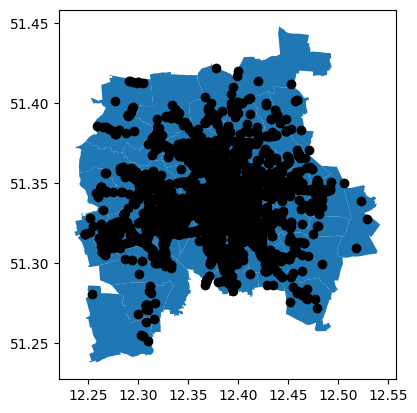

In [63]:
ax = groceries.plot(color='k', zorder=2)

chicago.plot(ax=ax, zorder=1);

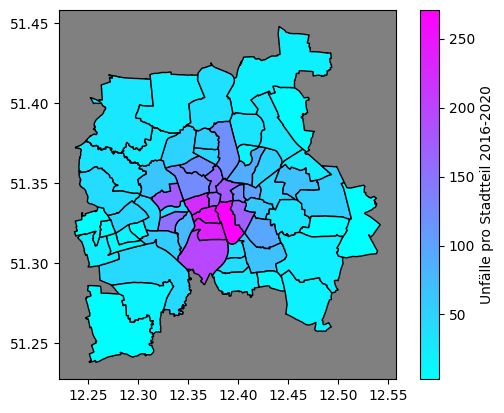

In [47]:
# Plot population estimates with an accurate legend

base = shape_einwohn_leip_uf.plot(

    column="count",

    legend=True,

    legend_kwds={"label": "Unfälle pro Stadtteil 2016-2020"},

    cmap="cool",

    edgecolor='black'
);

base.set_facecolor("grey")

plt.savefig("./plots/2.png")


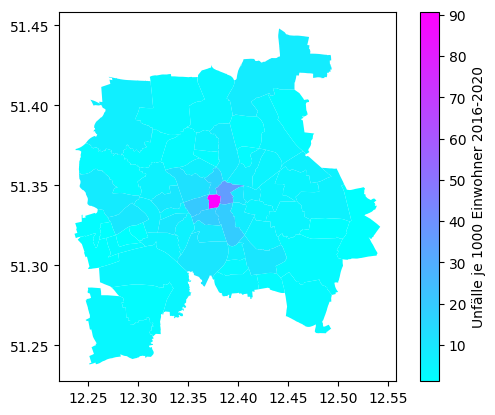

In [49]:
shape_einwohn_leip_uf.plot(

    column="Uf_Ew1000",

    legend=True,

    legend_kwds={"label": "Unfälle je 1000 Einwohner 2016-2020"},

    cmap="cool",

);

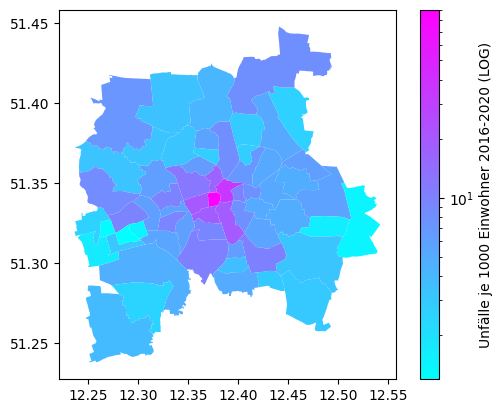

In [50]:
import matplotlib

# Plot population estimates with an accurate legend

shape_einwohn_leip_uf.plot(

    column="Uf_Ew1000",

    legend=True,

    legend_kwds={"label": "Unfälle je 1000 Einwohner 2016-2020 (LOG)", "fmt": "{:.0f}" },

    norm=matplotlib.colors.LogNorm(
        #vmin=shape_einwohn_leip_uf.Uf_Ew1000.min(), vmax=shape_einwohn_leip_uf.Uf_Ew1000.max()
        #clip=True,
    ),

    cmap="cool",


);

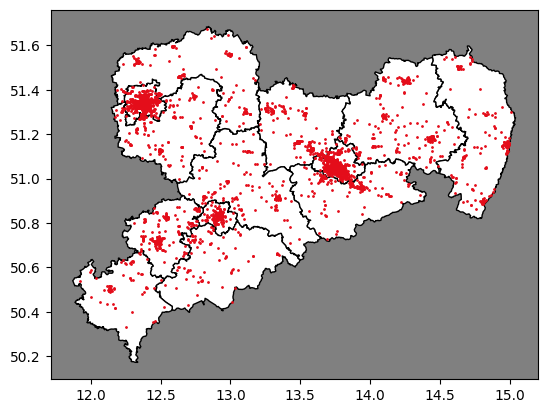

In [27]:
base = sax_df.plot(color='white', edgecolor='black')
base.set_facecolor("grey")

#ua2016sax = ua2016["ULAND"]==14
#print(ua2016["ULAND"]==14)
ua2016sax = ua2016.loc[(ua2016["ULAND"]==14) & (ua2016["IstRad"]==1)]

ua2016sax.plot(ax=base, marker='o', color='#e40d1a', markersize=1, alpha=1);

#plt.savefig("./plots/1.png")

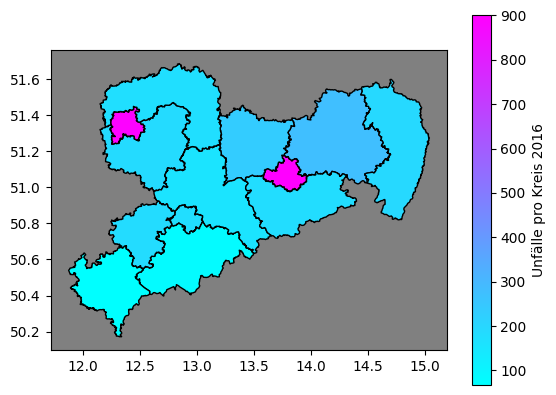

In [70]:
# Plot population estimates with an accurate legend

base = shape_sax_rad.plot(

    column="count",

    legend=True,

    legend_kwds={"label": "Unfälle pro Kreis 2016"},

    cmap="cool",

    edgecolor='black'
);

base.set_facecolor("grey")

#plt.savefig("./plots/2.png")

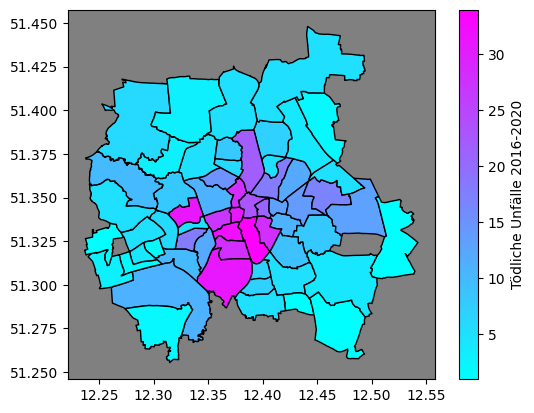

In [26]:
uf = ua_leip_20162020.loc[(ua_leip_20162020["UKATEGORIE"]<3) ]

uf.plot(ax=base, marker='o', color='#e40d1a', markersize=1, alpha=1);

x1_raw = uf.sjoin(leip_df, how="inner", predicate='intersects')
x1 = x1_raw["Name"].value_counts()
x2 = leip_df.merge(x1, on="Name", how="left")


base = x2.plot(

    column="count",

    legend=True,

    legend_kwds={"label": "Tödliche Unfälle 2016-2020"},

    cmap="cool",

    edgecolor='black'
)

base.set_facecolor("grey")

del(uf)
del(x1)
del(x1_raw)
del(x2)



In [27]:
ua2016 = ua2016.drop("FID", axis=1)
ua2017 = ua2017.drop("UIDENTSTLA", axis=1)
ua2017 = ua2017.rename(columns = {"LICHT":"ULICHTVERH"})
ua2018 = ua2018.rename(columns = {"OBJECTID_1":"OBJECTID"})

ua2020 = ua2020.drop("UIDENTSTLAE", axis=1)
ua2021 = ua2021.drop("UIDENTSTLAE", axis=1)
ua2021 = ua2021.rename(columns = {"OID_":"OBJECTID"})
ua2022 = ua2022.drop("UIDENTSTLAE", axis=1)
ua2023 = ua2023.drop("UIDENTSTLAE", axis=1)
ua2023 = ua2023.rename(columns = {"OID_":"OBJECTID"})
ua2023 = ua2023.drop("PLST", axis=1)

ua2016 = ua2016.drop("IstGkfz", axis=1)
ua2018 = ua2018.drop("IstGkfz", axis=1)
ua2019 = ua2019.drop("IstGkfz", axis=1)
ua2020 = ua2020.drop("IstGkfz", axis=1)
ua2021 = ua2021.drop("IstGkfz", axis=1)
ua2022 = ua2022.drop("IstGkfz", axis=1)
ua2023 = ua2023.drop("IstGkfz", axis=1)

ua2016 = ua2016.rename(columns = {"IstStrasse":"STRZUSTAND"})
ua2021 = ua2021.rename(columns = {"IstStrassenzustand":"STRZUSTAND"})
ua2022 = ua2022.rename(columns = {"IstStrassenzustand":"STRZUSTAND"})
ua2023 = ua2023.rename(columns = {"IstStrassenzustand":"STRZUSTAND"})

ua2019 = ua2019.rename(columns = {"IstSonstige":"IstSonstig"})
ua2020 = ua2020.rename(columns = {"IstSonstige":"IstSonstig"})
ua2021 = ua2021.rename(columns = {"IstSonstige":"IstSonstig"})
ua2022 = ua2022.rename(columns = {"IstSonstige":"IstSonstig"})
ua2023 = ua2023.rename(columns = {"IstSonstige":"IstSonstig"})


ua2016 = ua2016.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2017 = ua2017.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2018 = ua2018.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2019 = ua2019.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2020 = ua2020.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2021 = ua2021.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2022 = ua2022.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2023 = ua2023.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]


In [28]:
frames = [ua2016, ua2017, ua2018, ua2019, ua2020, ua2021, ua2022, ua2023]

result = pd.concat(frames)
result = result.loc[(result["ULAND"]==14) & (result["IstRad"]==1)]
result_leip = result.loc[(result["ULAND"]==14) & (result["IstRad"]==1) & (result["UREGBEZ"]==7) & (result["UKREIS"]==13)]



In [29]:
shape_einwohn_sax = sax_df.merge(einwohn_sax, on="KREIS", how="left")

uf_pro_Kreis_raw = result.sjoin(sax_df, how="inner", predicate='intersects')
uf_pro_Kreis = uf_pro_Kreis_raw["KREIS"].value_counts()

shape_einwohn_sax_uf = shape_einwohn_sax.merge(uf_pro_Kreis, on="KREIS", how="left")
shape_einwohn_sax_uf["Uf_Ew"] = shape_einwohn_sax_uf["count"] / shape_einwohn_sax_uf["2023"]
shape_einwohn_sax_uf["Uf_Ew1000"] = shape_einwohn_sax_uf["count"] / shape_einwohn_sax_uf["2023"] * 1000

/home/fabian/PycharmProjects/DSH_Projekt/DigitalSpacialHumanities/.venv/lib/python3.12/site-packages/geopandas/geodataframe.py:2560: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:4269

  return geopandas.sjoin(


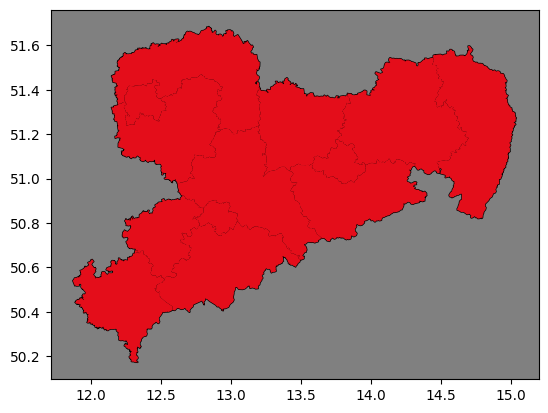

In [116]:
base = shape_einwohn_sax_uf.plot(color='white', edgecolor='black')
base.set_facecolor("grey")

shape_einwohn_sax_uf.plot(ax=base, marker='o', color='#e40d1a', markersize=1, alpha=1);

#plt.savefig("./plots/1.png")

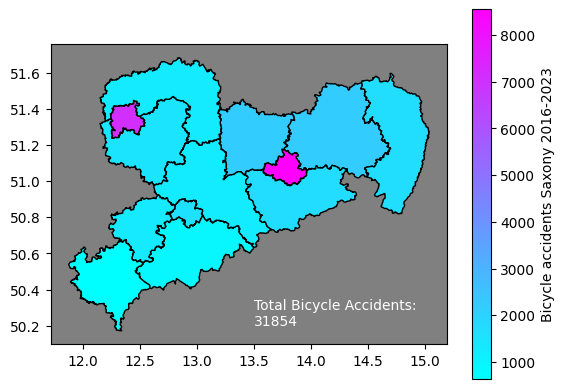

In [52]:
base = shape_einwohn_sax_uf.plot(

    column="count",

    legend=True,

    legend_kwds={"label": "Bicycle accidents Saxony 2016-2023"},

    cmap="cool",

    edgecolor='black'
);

base.text(13.5, 50.2,"Total Bicycle Accidents:\n31854", color='white');
base.set_facecolor("grey")
plt.savefig("./plots/3.png")

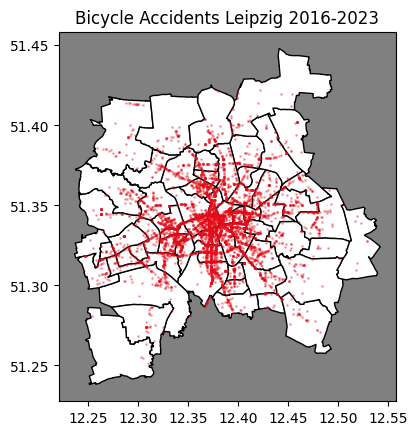

In [44]:
base = shape_einwohn_leip.plot(color='white', edgecolor='black')
base.set_facecolor("grey")
base.set_title('Bicycle Accidents Leipzig 2016-2023')

result_leip.plot(ax=base, marker='o', color='#e40d1a', markersize=1, alpha=0.3);

plt.savefig("./plots/1.png")

In [30]:
uf_pro_ST_raw_gsmt = result_leip.sjoin(leip_df, how="inner", predicate='intersects')
uf_pro_ST_gsmt = uf_pro_ST_raw_gsmt["Name"].value_counts()

shape_einwohn_leip_uf_gsmt = shape_einwohn_leip.merge(uf_pro_ST_gsmt, on="Name", how="left")
shape_einwohn_leip_uf_gsmt["Uf_Ew"] = shape_einwohn_leip_uf_gsmt["count"] / shape_einwohn_leip_uf_gsmt["2020"]
shape_einwohn_leip_uf_gsmt["Uf_Ew1000"] = shape_einwohn_leip_uf_gsmt["count"] / shape_einwohn_leip_uf_gsmt["2020"] * 1000

/home/fabian/PycharmProjects/DSH_Projekt/DigitalSpacialHumanities/.venv/lib/python3.12/site-packages/geopandas/geodataframe.py:2560: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:4269

  return geopandas.sjoin(


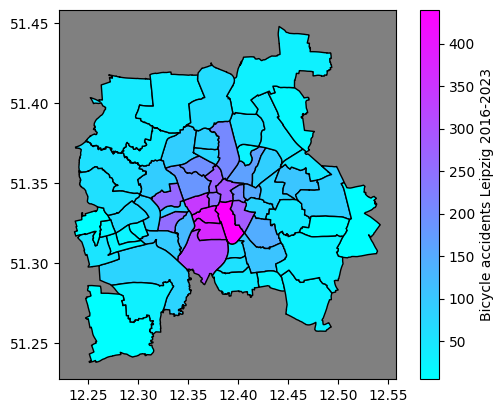

In [50]:
# Plot population estimates with an accurate legend

base = shape_einwohn_leip_uf_gsmt.plot(

    column="count",

    legend=True,

    legend_kwds={"label": "Bicycle accidents Leipzig 2016-2023"},

    cmap="cool",

    edgecolor='black'
);

base.set_facecolor("grey")

plt.savefig("./plots/2.png")

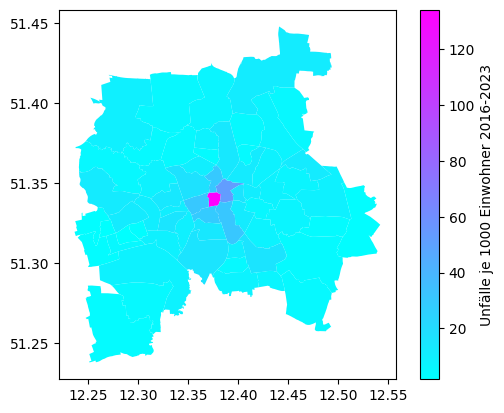

In [52]:
shape_einwohn_leip_uf_gsmt.plot(

    column="Uf_Ew1000",

    legend=True,

    legend_kwds={"label": "Unfälle je 1000 Einwohner 2016-2023"},

    cmap="cool",

);

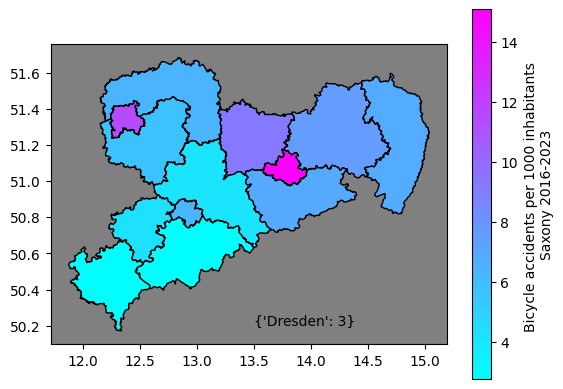

In [31]:
base = shape_einwohn_sax_uf.plot(

    column="Uf_Ew1000",

    legend=True,

    legend_kwds={"label": "Bicycle accidents per 1000 inhabitants \nSaxony 2016-2023"},

    cmap="cool",

    edgecolor='black'

);
#base.annotate('local max', xy=(12.3, 51.35), xytext=(13.5, 50.2), arrowprops=dict(facecolor='white', shrink=0.05, alpha=0.8),)

base.text(13.5, 50.2,{"Dresden":3})
text=[["Faible","Ng<1,5" ],["Moyenne","1,5<Ng<2,5"],[u"Elevee", "Ng>2,5"]]
colLabels = ["Exposition", u"Densite"]

base.set_facecolor("grey")
#plt.savefig("./plots/4.png")

In [ ]:
15.101850510930342
11.463527559410787
9.213799966827002
7.487200933539288
6.849287226993915
6.753085773848092
6.384960538439967
6.250972351315017
5.681014477793962
4.214619926413445
4.082475325332659
2.85195514365654
2.7470510498751897

In [ ]:
Dresden, Kreisfreie Stadt
Leipzig, Kreisfreie Stadt
Meißen
Bautzen
Sächsische Schweiz-Osterzgebirge
Görlitz
Nordsachsen
Chemnitz, Kreisfreie Stadt
Leipzig
Zwickau
Mittelsachsen
Vogtlandkreis
Erzgebirgskreis

In [106]:
# ua2016.info()
# ua2017.info()
# ua2018.info()
# ua2019.info()
# ua2020.info()
# ua2021.info()
# ua2022.info()
# ua2023.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 151673 entries, 0 to 151672
Data columns (total 24 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   OBJECTID    151673 non-null  int64   
 1   ULAND       151673 non-null  int64   
 2   UREGBEZ     151673 non-null  int64   
 3   UKREIS      151673 non-null  int64   
 4   UGEMEINDE   151673 non-null  int64   
 5   UJAHR       151673 non-null  int64   
 6   UMONAT      151673 non-null  int64   
 7   USTUNDE     151673 non-null  int64   
 8   UWOCHENTAG  151673 non-null  int64   
 9   UKATEGORIE  151673 non-null  int64   
 10  UART        151673 non-null  int64   
 11  UTYP1       151673 non-null  int64   
 12  ULICHTVERH  151673 non-null  int64   
 13  IstRad      151673 non-null  int64   
 14  IstPKW      151673 non-null  int64   
 15  IstFuss     151673 non-null  int64   
 16  IstKrad     151673 non-null  int64   
 17  IstSonstig  151673 non-null  int64   
 18  STRZUSTAND  1516